[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Shaarukesh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shaarukesh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


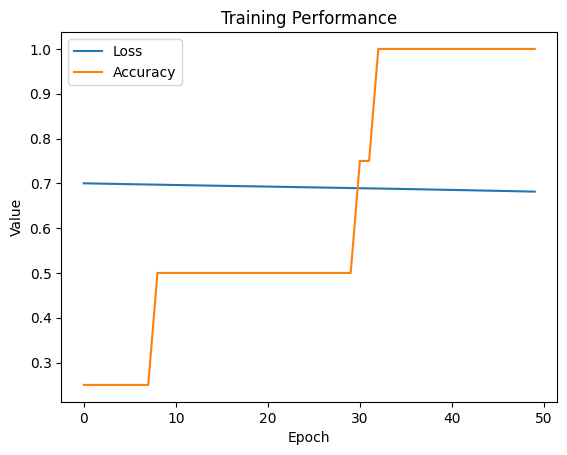

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


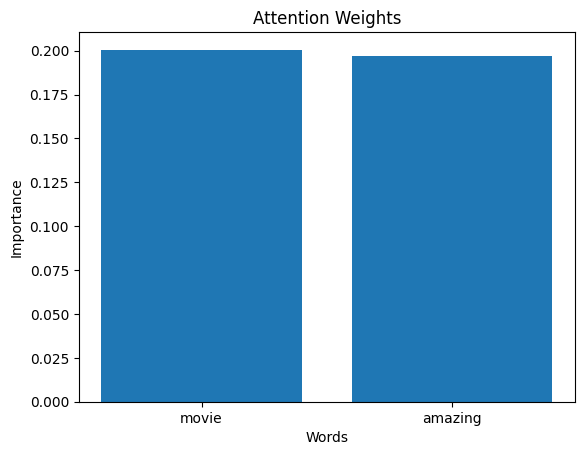

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


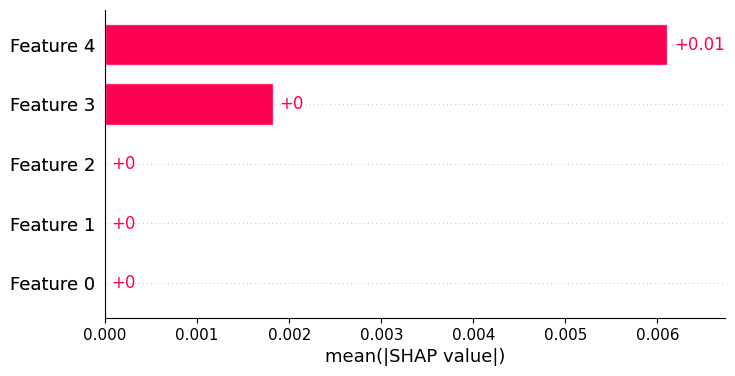

In [4]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import shap

from tensorflow.keras.layers import Embedding, Dense, Input, Layer
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# -----------------------------
# 1. Data
# -----------------------------
texts = [
    "The movie was amazing",
    "The movie was terrible",
    "The film was fantastic",
    "The film was boring"
]

labels = [1, 0, 1, 0]

# -----------------------------
# 2. NLP (NLTK)
# -----------------------------
stop_words = set(stopwords.words('english'))

def preprocess(text):
    tokens = word_tokenize(text.lower())
    tokens = [w for w in tokens if w.isalpha()]
    tokens = [w for w in tokens if w not in stop_words]
    return " ".join(tokens)

texts = [preprocess(t) for t in texts]

# -----------------------------
# 3. Tokenization
# -----------------------------
tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=5)
y = np.array(labels)

vocab_size = len(tokenizer.word_index) + 1

# -----------------------------
# 4. Attention Layer
# -----------------------------
class Attention(Layer):
    def call(self, inputs):
        weights = tf.nn.softmax(inputs, axis=1)
        context = weights * inputs
        return tf.reduce_sum(context, axis=1), weights

# -----------------------------
# 5. Model
# -----------------------------
inputs = Input(shape=(5,))
embedding = Embedding(vocab_size, 8)(inputs)

context, attn_weights = Attention()(embedding)

outputs = Dense(2, activation='softmax')(context)

model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# -----------------------------
# 6. Train + Plot Graph
# -----------------------------
history = model.fit(X, y, epochs=50, verbose=0)

# Plot Loss & Accuracy
plt.figure()
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['accuracy'], label='Accuracy')
plt.title("Training Performance")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.show()

# -----------------------------
# 7. Attention Visualization
# -----------------------------
attention_model = Model(inputs=inputs, outputs=attn_weights)

def show_attention(text):
    text_p = preprocess(text)
    seq = tokenizer.texts_to_sequences([text_p])
    seq = pad_sequences(seq, maxlen=5)

    weights = attention_model.predict(seq)[0]
    words = text_p.split()

    values = [float(w.mean()) for w in weights[-len(words):]]

    # Bar chart
    plt.figure()
    plt.bar(words, values)
    plt.title("Attention Weights")
    plt.xlabel("Words")
    plt.ylabel("Importance")
    plt.show()

# Example
show_attention("The movie was amazing")

# -----------------------------
# 8. SHAP Visualization
# -----------------------------
def predict_fn(x):
    return model.predict(x)

explainer = shap.Explainer(predict_fn, X)
shap_values = explainer(X)

# Bar plot (feature importance)
# Bar plot (feature importance) for class 1 (fix multi-output shape issue)
shap_values_class1 = shap_values[..., 1]
shap.plots.bar(shap_values_class1)

In [2]:
%pip install shap

  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ---------------------------------------- 556.1/556.1 kB 1.9 MB/s  0:00:00
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
    --------------------------------------- 0.8/38.1 MB 1.1 MB/s eta 0:00:34
   - -------------------------------------- 1.0/38.1 MB 1.2 MB/s eta 0:00:31
   - -------------------------------------- 1.6/38.1 MB 1.6 MB/s eta 0:00:24
   -- ------------------------------------- 2.1/38.1 MB 1.8 MB/s eta 0:00:21
   -- ------------------------------------- 2.1/38.1 MB 1.8 MB/s eta 0:00:21
   -- ------------------------------------- 2.4/38.1 MB 1.5 MB


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
